# 05 — Self-Attention: Letting Tokens Look at Each Other

**Lecture goal:** understand the problem self-attention solves, build a simplified (non-trainable) version by hand to see the mechanism clearly, then build the real, trainable version (queries, keys, values) that transformers actually use.

## The problem: embeddings are context-blind

The embedding from notebook 04 for the word `"bank"` is *exactly the same vector* whether the sentence is "I sat by the river **bank**" or "I deposited money at the **bank**." The embedding layer has no idea what other words surround a token — it's a fixed lookup table.

But meaning depends on context. What we want: a mechanism that lets every token's vector get *updated* by mixing in information from the other relevant tokens around it — "bank" near "river" should shift toward a riverbank-ish meaning; "bank" near "deposited" should shift toward a financial-institution meaning. That mechanism is **self-attention**, and it's the single most important idea in the transformer architecture.

## Setting up a toy example

We'll work with a tiny, easy-to-inspect example: 6 tokens (imagine the sentence *"Your journey starts with one step"*), each already embedded as a 3-number vector (in reality this would be the 256+ dimensional output of notebook 04 — we're shrinking it purely so we can print and read the numbers).

In [1]:
import torch

inputs = torch.tensor([
    [0.43, 0.15, 0.89],  # Your
    [0.55, 0.87, 0.66],  # journey
    [0.57, 0.85, 0.64],  # starts
    [0.22, 0.58, 0.33],  # with
    [0.77, 0.25, 0.10],  # one
    [0.05, 0.80, 0.55],  # step
])
print("shape:", inputs.shape)  # (num_tokens, embedding_dim) = (6, 3)

shape: torch.Size([6, 3])


## Part 1: Simplified self-attention (no learnable parameters yet)

Let's build intuition with the simplest version possible, focusing on a single query token first: `"journey"` (index 1). The question self-attention asks is: **"for this token, how relevant is every other token in the sequence (including itself)?"**

### Step 1 — Attention scores via dot product

We measure relevance between two vectors using the **dot product**: multiply corresponding elements and sum the results. For vectors `a = [a1, a2, a3]` and `b = [b1, b2, b3]`:

```
a . b = a1*b1 + a2*b2 + a3*b3
```

Geometrically, the dot product is large and positive when two vectors point in a similar direction (large magnitude, small angle between them), close to zero when they're roughly perpendicular (unrelated), and negative when they point in opposite directions. It's a cheap, effective similarity score.

We compute the dot product between our query (`"journey"`'s vector) and *every* token's vector, including its own.

In [2]:
query = inputs[1]  # "journey"

attention_scores_journey = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attention_scores_journey[i] = torch.dot(x_i, query)

print("Raw attention scores for query \'journey\':", attention_scores_journey)

Raw attention scores for query 'journey': tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


### Step 2 — Turn scores into weights with softmax

These raw scores aren't directly usable yet: they can be any real number, positive or negative, and we want something we can interpret as "how much attention to pay," which should be non-negative and sum to 1 (like a probability distribution).

**Softmax** does exactly this. For a vector of scores `z = [z1, ..., zn]`:

```
softmax(z)_i = exp(z_i) / sum_j(exp(z_j))
```

In words: exponentiate every score (this makes everything positive, and *amplifies* differences — a score that's a bit bigger becomes a lot bigger after exponentiating), then divide by the sum of all the exponentiated scores so everything adds up to exactly 1.

In [3]:
def softmax_naive(x):
    exp_x = torch.exp(x)
    return exp_x / exp_x.sum()

attention_weights_journey = softmax_naive(attention_scores_journey)
print("Attention weights:", attention_weights_journey)
print("Sum of weights:   ", attention_weights_journey.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum of weights:    tensor(1.)


(In practice we'll use PyTorch's built-in `torch.softmax`, which is numerically more stable for large or very negative scores than the naive formula above — but produces identical results.) Notice `"journey"` pays the *most* attention to itself (index 1) and to `"starts"` (index 2, its vector is numerically close to `"journey"`'s) — that tracks, since the dot product rewards similar vectors, and a token is always maximally similar to itself.

### Step 3 — Context vector: a weighted blend of all tokens' information

Now we use these weights to build a new vector for `"journey"`: instead of "just its own embedding," it becomes a **weighted sum of every token's embedding**, using the attention weights we just computed. This new, blended vector is called the **context vector**.

In [4]:
context_vector_journey = torch.zeros(query.shape)
for i, x_i in enumerate(inputs):
    context_vector_journey += attention_weights_journey[i] * x_i

print("Context vector for \'journey\':", context_vector_journey)

Context vector for 'journey': tensor([0.4419, 0.6515, 0.5683])


That's the whole mechanism, for one token. `"journey"`'s original embedding only knew about `"journey"`; its context vector is now a blend that leans heavily on itself and `"starts"`, with smaller contributions from the rest — exactly the "context-aware" representation we wanted.

## Doing this for every token at once, with matrix multiplication

Looping over each query token in Python would work but is slow and doesn't reflect how this is actually implemented. Instead, we compute attention scores for *all* query-token pairs simultaneously using **matrix multiplication**.

Recall: `inputs` has shape `(6, 3)` — 6 tokens, 3 numbers each. If we multiply `inputs` by its own transpose (`inputs.T`, shape `(3, 6)`), matrix multiplication rules say: `(6, 3) @ (3, 6) -> (6, 6)`. Entry `[i, j]` of the result is exactly `inputs[i] . inputs[j]` — the dot product between token `i` and token `j`. In other words, **one matrix multiplication computes every pairwise dot product at once.**

In [5]:
attention_scores = inputs @ inputs.T
print("All pairwise attention scores, shape:", attention_scores.shape)
print(attention_scores)

All pairwise attention scores, shape: torch.Size([6, 6])
tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


Row `1` of this matrix is exactly the `attention_scores_journey` we computed by hand above — check it matches. Now apply softmax to *each row* (so each token's scores across all other tokens sum to 1) using `dim=-1`, meaning "normalize along the last dimension":

In [6]:
attention_weights = torch.softmax(attention_scores, dim=-1)
print(attention_weights)
print()
print("Each row sums to 1:", attention_weights.sum(dim=-1))

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

Each row sums to 1: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


And finally, one more matrix multiplication produces every context vector at once: `(6, 6) @ (6, 3) -> (6, 3)` — for each of the 6 tokens, a weighted sum over all 6 value vectors.

In [7]:
all_context_vectors = attention_weights @ inputs
print(all_context_vectors)
print()
print("Matches our by-hand result for 'journey' (row 1)?", torch.allclose(all_context_vectors[1], context_vector_journey))

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

Matches our by-hand result for 'journey' (row 1)? True


## Part 2: Trainable self-attention (queries, keys, values)

The simplified version above has **zero learnable parameters** — it directly reuses the input embeddings both as the thing being compared (query and key) and the thing being blended (value). That's too rigid: we want the model to *learn* what makes two tokens "relevant" to each other, rather than hard-coding "relevant = similar raw embedding."

The fix, introduced in the original "Attention Is All You Need" paper: project each input embedding through **three separate learned weight matrices** before doing anything else:

- **Query** (`W_query`): "what am I looking for?" — a transformed view of the current token, used to search.
- **Key** (`W_key`): "what do I contain?" — a transformed view of every token, used to be searched *against*.
- **Value** (`W_value`): "what information do I actually offer?" — a transformed view of every token, used to build the blended output.

Splitting one embedding into three different learned projections gives the model the flexibility to learn, e.g., "compare tokens using their grammatical role (query/key), but blend using their semantic content (value)" — far more expressive than reusing the same vector for everything.

`x @ W` is matrix multiplication again: an input vector `x` of shape `(embedding_dim,)` times a weight matrix `W` of shape `(embedding_dim, d_out)` produces a new vector of shape `(d_out,)` — `d_out` doesn't have to equal `embedding_dim`, giving us control over the size of these projected spaces.

### Building intuition: think of it as a tiny search engine

Before the formulas, here's the plain-English picture. Imagine every token running its own miniature search:

- Its **query** is the search box: "given what I am, what kind of information am I looking for from the rest of the sentence?"
- Every token (including itself) also publishes a **key** — like a label or tag on a document: "here's how to describe what I have to offer, in searchable terms."
- Every token also publishes a **value** — the actual content behind that label: "here's what you actually get if you pick me."

To score how relevant token B is to token A's question, compare A's *query* against B's *key* (dot product — "how well does this label match what I'm looking for?"). Do that against every key, softmax the results into percentages that sum to 1 ("how much of my attention budget goes to each token"), then use those percentages to take a weighted blend of everyone's *value* vectors. That blend becomes token A's new, context-aware representation.

**Why three separate matrices, and not one?** "What am I searching for," "how do I advertise myself to be found," and "what do I actually hand over once picked" are three different jobs, and a token may need a different vector for each. Consider `"bank"` — to be *found* by both a "river" context and a "deposit" context it needs a flexible key, but what it actually *contributes* as value once selected can differ depending on which meaning is active. Forcing one vector to do all three jobs — exactly what the simplified version above did, by literally reusing `inputs` as query, key, *and* value — throws away that flexibility.

Query, key, and value are all computed as `x @ W`: the *same* input vector `x`, pushed through three *different* learned matrices — three different lenses on the same token. In the code below, `W_query`, `W_key`, `W_value` are each `(d_in, d_out)` matrices, `(3, 2)` here. They start out random, exactly like every embedding table we've built so far, and get shaped by backpropagation the same way once real training starts in notebook 10 — nudged so that, for token pairs where attending to each other actually helps predict the next token, `query . key` comes out large.

### Making it concrete: a YouTube search

Abstract "search engine" talk can still feel slippery, so let's ground it in a search you've actually done. You type "funny cat videos" into YouTube's search bar — that's your **query**. YouTube doesn't compare your query against the raw video files (way too much data, and not directly comparable to text anyway); it compares your query against each video's **title**, description, tags — the **keys**, a compact, searchable summary of what each video is about. Whichever titles match best get *weighted highest*, and what actually gets returned to you is the **value** — the video content itself, most of it drawn from the best-matching few, a little bleeding in from close-but-not-quite matches, essentially nothing from totally irrelevant videos.

Self-attention runs exactly this process for every token, against every other token, simultaneously — except instead of hard "top-10 results," it keeps *all* of them, weighted continuously by softmax (a **soft** match, not an exact one). The diagram below visualizes one such search: a query token compared against three candidate "keys," with the resulting similarity weights determining how much each candidate's "value" content flows into the final blended result.

There's also a sharper way to state *why one embedding vector can't play all three roles at once* (query, key, and value): a token's embedding bundles together many kinds of information at once — spelling/lexical form, grammatical role, topical/semantic meaning, and more — smeared together into one vector. Which of those aspects matters depends on the job. Comparing "how similar are these two tokens' grammatical roles" and "what semantic content should flow into the output" are different questions, potentially needing different slices of that bundled information. A single learned matrix `W_query` (or `W_key`, or `W_value`) gives the network a dedicated, trainable "filter" that can extract *just* the aspect of the embedding relevant to that one job, rather than forcing every comparison to use the whole undifferentiated vector. *(Framing adapted from [Yet Another Explanation of QKV in Transformers](https://epichka.com/blog/2023/qkv-transformer/), which is worth reading for another take on this same idea.)*

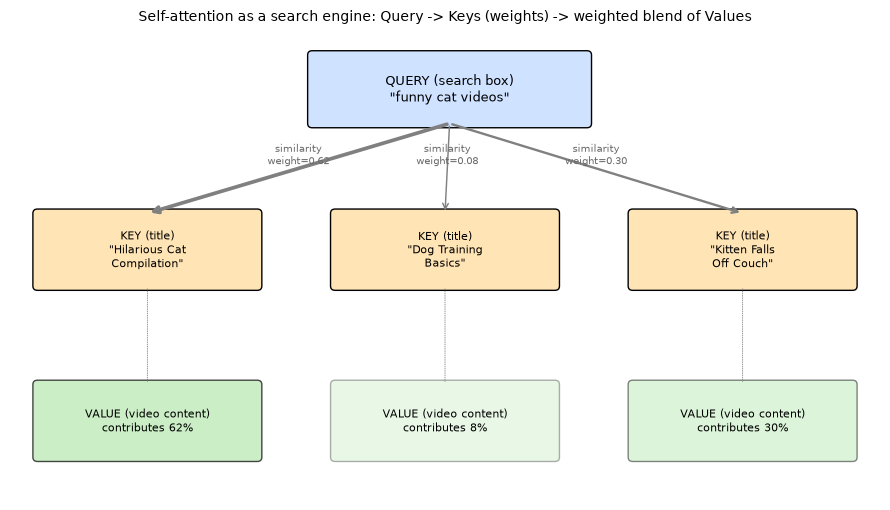

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.axis("off")

query_xy = (3.3, 4.1)
ax.add_patch(mpatches.FancyBboxPatch(query_xy, 3.0, 0.8, boxstyle="round,pad=0.05",
                                      edgecolor="black", facecolor="#cfe2ff"))
ax.text(query_xy[0] + 1.5, query_xy[1] + 0.4, "QUERY (search box)\n\"funny cat videos\"",
        ha="center", va="center", fontsize=9)

titles = ["Hilarious Cat\nCompilation", "Dog Training\nBasics", "Kitten Falls\nOff Couch"]
weights = [0.62, 0.08, 0.30]  # illustrative softmax output, sums to 1
xs = [0.3, 3.55, 6.8]
key_y = 2.2
val_y = 0.2

for x, title, w in zip(xs, titles, weights):
    ax.add_patch(mpatches.FancyBboxPatch((x, key_y), 2.4, 0.85, boxstyle="round,pad=0.05",
                                          edgecolor="black", facecolor="#ffe4b5"))
    ax.text(x + 1.2, key_y + 0.42, f"KEY (title)\n\"{title}\"", ha="center", va="center", fontsize=8)

    ax.annotate("", xy=(x + 1.2, key_y + 0.85), xytext=(query_xy[0] + 1.5, query_xy[1]),
                arrowprops=dict(arrowstyle="->", color="gray", lw=0.8 + 3 * w))
    mx, my = (x + 1.2 + query_xy[0] + 1.5) / 2, (key_y + 0.85 + query_xy[1]) / 2
    ax.text(mx, my + 0.05, f"similarity\nweight={w:.2f}", fontsize=7, color="dimgray", ha="center")

    alpha = 0.25 + 0.75 * w
    ax.add_patch(mpatches.FancyBboxPatch((x, val_y), 2.4, 0.85, boxstyle="round,pad=0.05",
                                          edgecolor="black", facecolor="#b7e8b0", alpha=alpha))
    ax.text(x + 1.2, val_y + 0.42, f"VALUE (video content)\ncontributes {w:.0%}",
            ha="center", va="center", fontsize=8)

    ax.annotate("", xy=(x + 1.2, val_y + 0.85), xytext=(x + 1.2, key_y),
                arrowprops=dict(arrowstyle="-", color="gray", lw=0.6, linestyle=":"))

ax.set_xlim(0, 9.5)
ax.set_ylim(-0.3, 5.2)
ax.set_title("Self-attention as a search engine: Query -> Keys (weights) -> weighted blend of Values",
             fontsize=10)
plt.tight_layout()
plt.show()

The `weight=0.62 / 0.08 / 0.30` numbers on the arrows above are exactly the kind of output `torch.softmax` produces — three numbers that sum to 1, one per candidate, big when the query-key match is strong. That's precisely what the code below computes, just with real tensors instead of made-up illustrative numbers, and with 6 tokens attending to each other instead of 1 query against 3 candidates.

In [9]:
torch.manual_seed(123)

d_in = inputs.shape[1]  # embedding dimension of the input = 3
d_out = 2                # we choose the dimension of the query/key/value space; GPT-2 uses larger values

W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

queries = inputs @ W_query
keys = inputs @ W_key
values = inputs @ W_value

print("queries shape:", queries.shape)
print("keys shape:   ", keys.shape)
print("values shape: ", values.shape)

queries shape: torch.Size([6, 2])
keys shape:    torch.Size([6, 2])
values shape:  torch.Size([6, 2])


(We set `requires_grad=False` here purely to keep this a clean, static example — in a real model these weights absolutely do need gradients, since learning *them* is the whole point of training. We'll flip this back on once we package everything into a proper class below.)

Now the same three steps as before, but using `queries`/`keys`/`values` instead of raw `inputs` directly:

1. Attention scores: `queries @ keys.T`
2. Scale, then softmax to get attention weights
3. Context vectors: `attention_weights @ values`

### Why scale the scores?

There's one new detail: before the softmax, we divide the scores by `sqrt(d_out)` (the square root of the key/query dimension). As `d_out` grows, dot products between random vectors tend to grow larger in magnitude too (more terms being summed). Very large scores push softmax into a regime where it becomes extremely "peaked" — one weight near 1, the rest near 0 — which in turn makes gradients during training vanishingly small and learning unstable. Dividing by `sqrt(d_out)` keeps the scores, and therefore the softmax output, in a well-behaved range regardless of how large `d_out` is. This is called **scaled dot-product attention**.

In [10]:
attention_scores = queries @ keys.T
d_k = keys.shape[-1]
attention_weights = torch.softmax(attention_scores / d_k**0.5, dim=-1)

print(attention_weights)
print()
print("Each row still sums to 1:", attention_weights.sum(dim=-1))

tensor([[0.1551, 0.2104, 0.2059, 0.1413, 0.1074, 0.1799],
        [0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820],
        [0.1503, 0.2256, 0.2192, 0.1315, 0.0914, 0.1819],
        [0.1591, 0.1994, 0.1962, 0.1477, 0.1206, 0.1769],
        [0.1610, 0.1949, 0.1923, 0.1501, 0.1265, 0.1752],
        [0.1557, 0.2092, 0.2048, 0.1419, 0.1089, 0.1794]])

Each row still sums to 1: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


### A detail worth noticing: attention is no longer symmetric

Back in Part 1, `attention_scores = inputs @ inputs.T` was symmetric — token A's score for token B always equaled token B's score for token A, since both directions used the exact same vector twice. That's a real limitation: relevance in language is often one-directional. In "the trophy didn't fit in the suitcase because **it** was too big," `"it"` should attend strongly to `"trophy"`, but `"trophy"` doesn't need to attend back to `"it"` nearly as strongly.

Now that queries come from `W_query` and keys come from a *different* matrix `W_key`, `attention_scores = queries @ keys.T` is generally **not** symmetric: entry `[i, j]` is `query_i . key_j` (token i's question matched against token j's label), while entry `[j, i]` is `query_j . key_i` — a different comparison entirely, since queries and keys live in different learned spaces. Let's confirm this with the actual numbers:

In [11]:
print("Symmetric?", torch.allclose(attention_scores, attention_scores.T))
print(attention_scores)

Symmetric? False
tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])


In [12]:
context_vectors = attention_weights @ values
print("Context vectors shape:", context_vectors.shape)
print(context_vectors)

Context vectors shape: torch.Size([6, 2])
tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]])


## Packaging this into a reusable `SelfAttention` module

Let's wrap the trainable version into a proper `torch.nn.Module` — the standard base class for any component with learnable parameters in PyTorch. Two things every `nn.Module` subclass needs:

- `__init__`: define the learnable pieces (here, the three weight matrices, using `nn.Linear` — a standard "multiply by a weight matrix" layer — instead of raw `nn.Parameter`, since `nn.Linear` handles good weight initialization for us).
- `forward`: define what happens when the module is called on an input — exactly the three steps above.

In [13]:
import torch.nn as nn


class SelfAttention(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        queries = self.W_query(x)
        keys = self.W_key(x)
        values = self.W_value(x)

        attention_scores = queries @ keys.T
        attention_weights = torch.softmax(attention_scores / keys.shape[-1] ** 0.5, dim=-1)

        context_vectors = attention_weights @ values
        return context_vectors

In [14]:
torch.manual_seed(789)
self_attention = SelfAttention(d_in=3, d_out=2)
print(self_attention(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


## Recap

- Token embeddings alone are context-blind. **Self-attention** updates each token's representation by blending in information from every other token, weighted by relevance.
- Relevance is measured via **dot product** between query and key vectors; **softmax** turns raw scores into weights that sum to 1; the **context vector** is the weighted sum of value vectors.
- The simplified version reuses raw embeddings for everything; the real, **trainable** version projects inputs through three learned matrices (`W_query`, `W_key`, `W_value`) first, giving the model the flexibility to learn *what* to compare and *what* to retrieve.
- Scores are divided by `sqrt(d_out)` before the softmax (**scaled dot-product attention**) to keep training numerically stable as dimensions grow.

### What's next

Two pieces are still missing before this becomes the attention used inside GPT: **causal masking**, so a token can't "attend" to tokens that come after it (cheating by looking at the future during training), and **multi-head attention**, which runs several attention mechanisms in parallel so the model can track several different kinds of relationships at once. Both are in notebook 06.